In [1]:
from pathlib import Path
import json
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
DATA_DIR = Path("../data/raw/DAFA_LS")

LOOTED_DIR = DATA_DIR / "looted"
PRESERVED_DIR = DATA_DIR / "preserved"
FOLD_PATH = DATA_DIR / "fold_dict.json"

image_extensions = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]

In [3]:
print("Dataset folder content:")
for item in DATA_DIR.iterdir():
    print(item.name)

Dataset folder content:
fold_dict.json
LICENSE.txt
looted
preserved
README.txt


### open fold_dict.json

In [4]:
with open(FOLD_PATH, "r") as f:
    fold_dict = json.load(f)

print(fold_dict.keys())

dict_keys(['train', 'val_1', 'val_2', 'val_3', 'val_4', 'val_5', 'test'])


### Count samples in each split

In [5]:
split_summary = []

for split_name, split_data in fold_dict.items():
    looted_count = len(split_data["looted"])
    preserved_count = len(split_data["preserved"])
    total = looted_count + preserved_count
    
    split_summary.append({
        "split": split_name,
        "looted": looted_count,
        "preserved": preserved_count,
        "total": total,
        "looted_percentage": round(looted_count / total * 100, 2),
        "preserved_percentage": round(preserved_count / total * 100, 2)
    })

split_summary_df = pd.DataFrame(split_summary)
split_summary_df

,split,looted,preserved,total,looted_percentage,preserved_percentage
0,train,64,460,524,12.21,87.79
1,val_1,9,9,18,50.00,50.00
2,val_2,9,9,18,50.00,50.00
3,val_3,9,9,18,50.00,50.00
4,val_4,9,9,18,50.00,50.00
5,val_5,9,9,18,50.00,50.00
6,test,26,35,61,42.62,57.38


In [6]:
Path("../data/processed").mkdir(parents=True, exist_ok=True)
split_summary_df.to_csv("../data/processed/split_summary.csv", index=False)

In [7]:
print("Looted folder examples:")
for x in list(LOOTED_DIR.iterdir())[:10]:
    print(x.name)

print("\nPreserved folder examples:")
for x in list(PRESERVED_DIR.iterdir())[:10]:
    print(x.name)

Looted folder examples:
0
1
10
100
101
102
103
104
105
106

Preserved folder examples:
0
1
10
100
101
102
103
104
105
106


In [11]:
DATA_DIR / "looted" / str(site_id)

WindowsPath('../data/raw/DAFA_LS/looted/123')

In [12]:
DATA_DIR / "looted" / f"site_{site_id}"

WindowsPath('../data/raw/DAFA_LS/looted/site_123')

### Create one full dataframe from all splits

In [13]:
records = []

for split_name, split_data in fold_dict.items():
    
    for site_id in split_data["looted"]:
        records.append({
            "split": split_name,
            "site_id": str(site_id),
            "class_name": "looted",
            "label": 1,
            "site_path": str(LOOTED_DIR / str(site_id))
        })
    
    for site_id in split_data["preserved"]:
        records.append({
            "split": split_name,
            "site_id": str(site_id),
            "class_name": "preserved",
            "label": 0,
            "site_path": str(PRESERVED_DIR / str(site_id))
        })

labels_df = pd.DataFrame(records)

print(labels_df.head())
print(labels_df.groupby(["split", "class_name"]).size())

   split site_id class_name  label                     site_path
0  train       1     looted      1  ..\data\raw\DAFA_LS\looted\1
1  train       2     looted      1  ..\data\raw\DAFA_LS\looted\2
2  train       3     looted      1  ..\data\raw\DAFA_LS\looted\3
3  train       4     looted      1  ..\data\raw\DAFA_LS\looted\4
4  train       5     looted      1  ..\data\raw\DAFA_LS\looted\5
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64


In [14]:
labels_df.to_csv("../data/processed/labels_with_splits.csv", index=False)

In [15]:
missing_site_folders = []

for _, row in labels_df.iterrows():
    site_path = Path(row["site_path"])
    
    if not site_path.exists():
        missing_site_folders.append({
            "split": row["split"],
            "site_id": row["site_id"],
            "class_name": row["class_name"],
            "site_path": row["site_path"]
        })

missing_sites_df = pd.DataFrame(missing_site_folders)

print("Missing site folders:", len(missing_sites_df))
missing_sites_df.head()

Missing site folders: 0


""


In [16]:
missing_sites_df.to_csv("../data/processed/missing_site_folders.csv", index=False)

### Count frames per site

In [17]:
def get_frames(site_path):
    site_path = Path(site_path)
    frames = []
    
    for ext in image_extensions:
        frames.extend(list(site_path.glob(f"*{ext}")))
    
    return sorted(frames)

inventory = []

for _, row in labels_df.iterrows():
    frames = get_frames(row["site_path"])
    
    inventory.append({
        "split": row["split"],
        "site_id": row["site_id"],
        "class_name": row["class_name"],
        "label": row["label"],
        "site_path": row["site_path"],
        "total_frames": len(frames),
        "first_frame": frames[0].name if len(frames) > 0 else None,
        "last_frame": frames[-1].name if len(frames) > 0 else None
    })

inventory_df = pd.DataFrame(inventory)

print(inventory_df.head())
print(inventory_df["total_frames"].describe())

   split site_id class_name  label                     site_path  \
0  train       1     looted      1  ..\data\raw\DAFA_LS\looted\1   
1  train       2     looted      1  ..\data\raw\DAFA_LS\looted\2   
2  train       3     looted      1  ..\data\raw\DAFA_LS\looted\3   
3  train       4     looted      1  ..\data\raw\DAFA_LS\looted\4   
4  train       5     looted      1  ..\data\raw\DAFA_LS\looted\5   

   total_frames  first_frame last_frame  
0            95  2016_01.jpg   mask.png  
1            95  2016_01.jpg   mask.png  
2            95  2016_01.jpg   mask.png  
3            95  2016_01.jpg   mask.png  
4            95  2016_01.jpg   mask.png  
count    675.000000
mean      94.983704
std        1.805375
min       82.000000
25%       95.000000
50%       95.000000
75%       96.000000
max       96.000000
Name: total_frames, dtype: float64


In [18]:
inventory_df.to_csv("../data/processed/data_inventory.csv", index=False)

In [19]:
inventory_df[inventory_df["total_frames"] < 8]

,split,site_id,class_name,label,site_path,total_frames,first_frame,last_frame


In [20]:
metadata = []

for _, row in labels_df.iterrows():
    frames = get_frames(row["site_path"])
    
    for frame_index, frame_path in enumerate(frames):
        metadata.append({
            "split": row["split"],
            "site_id": row["site_id"],
            "class_name": row["class_name"],
            "label": row["label"],
            "frame_index": frame_index,
            "frame_name": frame_path.name,
            "frame_path": str(frame_path)
        })

metadata_df = pd.DataFrame(metadata)

print(metadata_df.head())
print("Total frames:", len(metadata_df))
print("Total sites:", metadata_df["site_id"].nunique())

   split site_id class_name  label  frame_index   frame_name  \
0  train       1     looted      1            0  2016_01.jpg   
1  train       1     looted      1            1  2016_02.jpg   
2  train       1     looted      1            2  2016_03.jpg   
3  train       1     looted      1            3  2016_04.jpg   
4  train       1     looted      1            4  2016_05.jpg   

                                 frame_path  
0  ..\data\raw\DAFA_LS\looted\1\2016_01.jpg  
1  ..\data\raw\DAFA_LS\looted\1\2016_02.jpg  
2  ..\data\raw\DAFA_LS\looted\1\2016_03.jpg  
3  ..\data\raw\DAFA_LS\looted\1\2016_04.jpg  
4  ..\data\raw\DAFA_LS\looted\1\2016_05.jpg  
Total frames: 64114
Total sites: 540


In [21]:
metadata_df.to_csv("../data/processed/metadata.csv", index=False)

In [22]:
image_info = []

for _, row in metadata_df.iterrows():
    img_path = Path(row["frame_path"])
    
    try:
        img = Image.open(img_path)
        width, height = img.size
        mode = img.mode
        
        image_info.append({
            "split": row["split"],
            "site_id": row["site_id"],
            "class_name": row["class_name"],
            "label": row["label"],
            "frame_name": row["frame_name"],
            "frame_path": row["frame_path"],
            "width": width,
            "height": height,
            "mode": mode
        })
        
    except Exception as e:
        image_info.append({
            "split": row["split"],
            "site_id": row["site_id"],
            "class_name": row["class_name"],
            "label": row["label"],
            "frame_name": row["frame_name"],
            "frame_path": row["frame_path"],
            "width": None,
            "height": None,
            "mode": None,
            "error": str(e)
        })

image_info_df = pd.DataFrame(image_info)

print(image_info_df[["width", "height", "mode"]].value_counts())

width  height  mode
266    266     RGB     63439
               L         675
Name: count, dtype: int64


In [23]:
image_info_df.to_csv("../data/processed/image_info.csv", index=False)

In [24]:
corrupted = []

for _, row in metadata_df.iterrows():
    img_path = Path(row["frame_path"])
    
    try:
        img = Image.open(img_path)
        img.verify()
    except Exception as e:
        corrupted.append({
            "split": row["split"],
            "site_id": row["site_id"],
            "class_name": row["class_name"],
            "label": row["label"],
            "frame_path": row["frame_path"],
            "error": str(e)
        })

corrupted_df = pd.DataFrame(corrupted)

print("Corrupted images:", len(corrupted_df))
corrupted_df.head()

Corrupted images: 0


""


In [25]:
corrupted_df.to_csv("../data/processed/corrupted_images.csv", index=False)

In [26]:
sample_site = labels_df.iloc[0]["site_path"]
sample_frames = get_frames(sample_site)

for frame in sample_frames[:20]:
    print(frame.name)

2016_01.jpg
2016_02.jpg
2016_03.jpg
2016_04.jpg
2016_05.jpg
2016_06.jpg
2016_08.jpg
2016_09.jpg
2016_10.jpg
2016_11.jpg
2016_12.jpg
2017_02.jpg
2017_03.jpg
2017_04.jpg
2017_05.jpg
2017_06.jpg
2017_07.jpg
2017_08.jpg
2017_09.jpg
2017_10.jpg


In [27]:
temporal_check = []

for _, row in labels_df.iterrows():
    frames = get_frames(row["site_path"])
    frame_names = [f.name for f in frames]
    
    temporal_check.append({
        "split": row["split"],
        "site_id": row["site_id"],
        "class_name": row["class_name"],
        "total_frames": len(frames),
        "first_5_frames": frame_names[:5],
        "last_5_frames": frame_names[-5:] if len(frame_names) >= 5 else frame_names
    })

temporal_check_df = pd.DataFrame(temporal_check)
temporal_check_df.head()

,split,site_id,class_name,total_frames,first_5_frames,last_5_frames
0,train,1,looted,95,"[2016_01.jpg, 2016_02.jpg, 2016_03.jpg, 2016_0...","[2023_09.jpg, 2023_10.jpg, 2023_11.jpg, 2023_1..."
1,train,2,looted,95,"[2016_01.jpg, 2016_02.jpg, 2016_03.jpg, 2016_0...","[2023_09.jpg, 2023_10.jpg, 2023_11.jpg, 2023_1..."
2,train,3,looted,95,"[2016_01.jpg, 2016_02.jpg, 2016_03.jpg, 2016_0...","[2023_09.jpg, 2023_10.jpg, 2023_11.jpg, 2023_1..."
3,train,4,looted,95,"[2016_01.jpg, 2016_02.jpg, 2016_03.jpg, 2016_0...","[2023_09.jpg, 2023_10.jpg, 2023_11.jpg, 2023_1..."
4,train,5,looted,95,"[2016_01.jpg, 2016_02.jpg, 2016_03.jpg, 2016_0...","[2023_09.jpg, 2023_10.jpg, 2023_11.jpg, 2023_1..."


In [28]:
temporal_check_df.to_csv("../data/processed/temporal_order_check.csv", index=False)

Looted sample
Site: ..\data\raw\DAFA_LS\looted\1
Frames found: 8


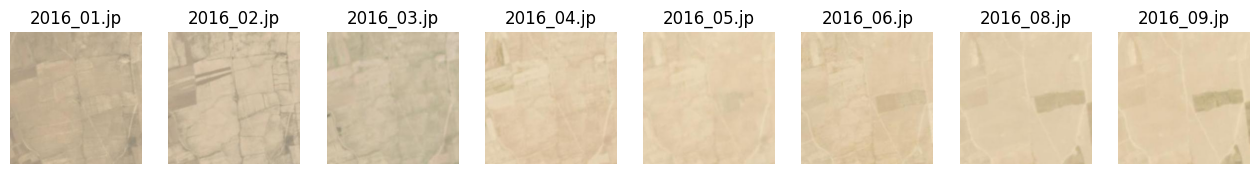

Preserved sample
Site: ..\data\raw\DAFA_LS\preserved\0
Frames found: 8


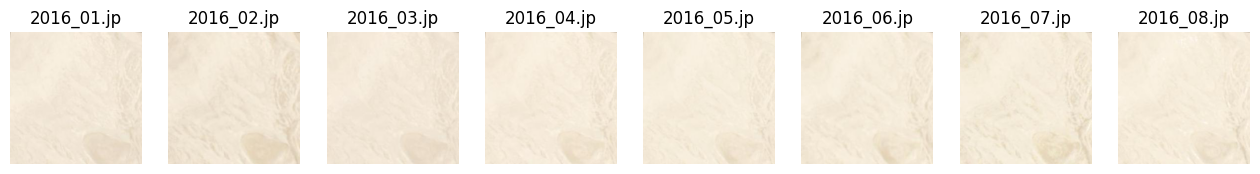

In [29]:
def show_site(site_path, n=8):
    frames = get_frames(site_path)[:n]
    
    print("Site:", site_path)
    print("Frames found:", len(frames))
    
    if len(frames) == 0:
        print("No frames found.")
        return
    
    plt.figure(figsize=(16, 4))
    
    for i, frame in enumerate(frames):
        img = Image.open(frame).convert("RGB")
        plt.subplot(1, len(frames), i + 1)
        plt.imshow(img)
        plt.title(frame.name[:10])
        plt.axis("off")
    
    plt.show()

looted_sample = labels_df[labels_df["label"] == 1].iloc[0]["site_path"]
preserved_sample = labels_df[labels_df["label"] == 0].iloc[0]["site_path"]

print("Looted sample")
show_site(looted_sample, n=8)

print("Preserved sample")
show_site(preserved_sample, n=8)

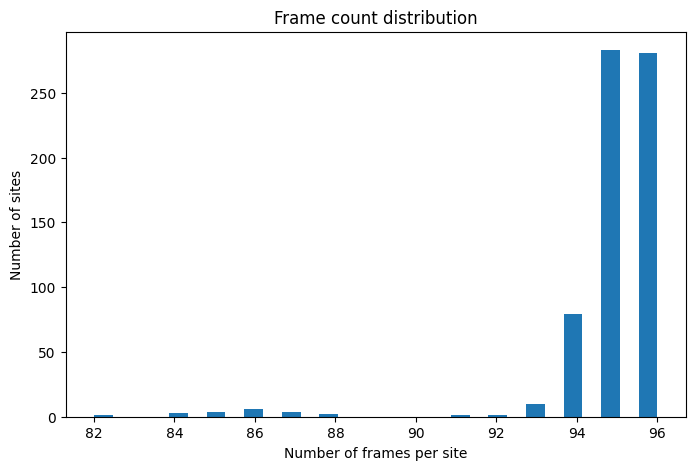

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(inventory_df["total_frames"], bins=30)
plt.xlabel("Number of frames per site")
plt.ylabel("Number of sites")
plt.title("Frame count distribution")
plt.show()

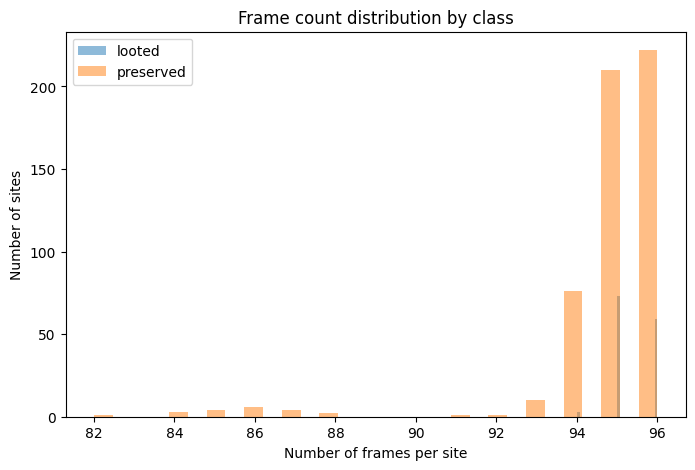

In [31]:
plt.figure(figsize=(8, 5))

for class_name in ["looted", "preserved"]:
    data = inventory_df[inventory_df["class_name"] == class_name]["total_frames"]
    plt.hist(data, bins=30, alpha=0.5, label=class_name)

plt.xlabel("Number of frames per site")
plt.ylabel("Number of sites")
plt.title("Frame count distribution by class")
plt.legend()
plt.show()